<a href="https://colab.research.google.com/github/gtzan/mir_book/blob/master/ch1_sinusoidworld/Explaining_the_DFT_a_music_perspective_part7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# A music and sound exposition of the Discrete Fourier Transform - Part 7
## Complex number notation

The Discrete Fourier Transform (DFT) is fundamental for any type of music and sound processing using computers. The goal of this notebook is to develop high-level intuition behind the concepts that underlie the DFT and understand how this transformation is used by various algorithms for audio analysis and synthesis. The intended audience is anyone with some knowledge of high school math that is interested in the topic. This is not a detailed mathematical digital signal processing (DSP) exposition. At the end of the notebook a variety of resources for better understanding the DFT and audio processing are provided for further digging.

There are many great resources for understanding the DFT including textbooks, tutorial articles, and videos some of which are listed at the end of this exposition. This material reflects my own personal way of teaching the DFT that has evolved over twenty years of experience with striving to explain the underlying concepts to students from diverse academic backgrounds and disciplines with a focus on how it connects to music information retrieval.


In **Part 1** we looked at how we can create complex sounds by combining sinudoids of different frequencies and amplitudes that change over time (additive synthesis) such as the sound of a bell or even the infamous THX sound. We also can create plausible and recognizable music melodies and tunes that are similar to the chip tunes made by the early game machines and computer sound cards.

In **Part 2** we started looked at the inverse problem of analysis. Given an array of audio samples that correspond to a complex sound or a simple melody we would like to find what are the frequencies and amplitudes of each sinusoidal component. We started by the simple problem of amplitude estimation of a single sinusoid and looked at peak and RMS amplitude. These methods were not very accurate in the presence of interference so we looked a estimating the amplitude through a dot-product (correlation) with probe/basis sinusoid with unit amplitude and frequency equal to the frequency we were looking for. This approach was shown to be very robust to the presence of interference but does require knowledge of the frequency you are training to estimate the amplitude for as well as phase alignment between the probe/basis and the target sinusoid.

In **Part 3** we looked at how we can deal with time and phase. For time we can perform short-time processing in which we process the audio samples in small chunks that are long enough to contain a few cycles of the sinusoids we are intrested in but short enough to allow us to estimate amplitudes that change over time.

To estimate the amplitude accurately when the probe/basis signal and the target sinusoid are not aligned in time we can calculate multiple amplitude estimate for different time shifts and select the maximum amplitude estimate as our amplitude estimate. This approach is called cross-correlation and is a fundamental digital signal processing operation with direct equivalents in mamallian auditory systems. It is a computationally costly operation as multiple dot-products need to be computed and the accuracy of the estimation depends on how many time shits are considered. It can also work for other waveforms than sinusoids. However, if we are dealing with sinusoids there is a much more efficient, clever way to estimate the amplitude.

If we are looking for the amplitude of a sinusoidal signal that is part of a complex signal and we know it's frequency we can take use inner-products of array corresponding to the complex signal that contains our "burried" sinusoid with two basis arrays (or probes) one containing a sampled sine signal of the known frequency and one containing a sampled cosine signal of the known frequency. The resulting two ampltitude estimates can be combined to return an estimate of the mangitude of the sinusoid as well as an estimate of the phase. Each of these sinusoids can be considered a "probe" or "basis" and is a building block that can take as input a complex input signal consisting of multiple sinusoidal signals and potentially other interferring sounds and estimate reliably the amplitude and the phase of of a sinusoid with a particular frequency of interest.

In **Part 4** we looked at how this basis/probe pair of a unit amplitude sine array of samples and a unit amplitude cosine array of samples form an amplitude and phase estimator for a particular frequency. By creating a linearly-spaced grid of frequencies we can create a transform that can change the representation of our signal from the time-domain to the frequency domain. The frequency domain (or spectrum) specifies how we can re-synthesize/re-construct our original time-domain signal by appropriately combining sinusoids with the estimated dot-product amplitudes with the two basis/probe signals from each frequency. These can be converted to actual amplitude and phase. To re-synthesize the sinusoidal components from the frequency domain we do not need to recompute samples of the sine and cosine function but can simply weigh each probe/basis appropriately and add them together. We called this the Discrete Probe Transform and showed that it can perform perfect reconstruction i.e we can get back our original input signal from the spectrum (frequency domain) without any loss of information. The Discrete Probe transform is essentially the Discrete Fourier Transform (DFT).

In **part 5** we formalize the DFT and start introducing some cool mathematical notation. The pair of basis/probes amplitude/phase estimator for a specific frequency is the basic building block and the key to understanding the DFT.


In **part 6** we look at how we can use the Discrete Fourier Transform for some cool audio applications namely spectral processing and spectrum/spectrogram visualizations.




In **part 7** we revisit the equations describing the Discrete Fourier Transform and sinusoids and explain in more detail the complex number notation that is typically used in Digitial Signal Processign textbooks and papers.


Let's revisit the heart of the Discrete Fourier Transform which the two inner-products of the input signal with the cosine and sine basis/probe signals and look at both the mathematical notation and the corresponding Python code.
In parts 1 through 6 we focused on intuitiion and understanding of programming
so hopefully the code makes sense. After the inner products we get two numbers which we can think of as amplitude estimates using the cosine probe array and the sine probe. Everything we need is additions/multiplications/arrays and the ability to evalute the cosine and sine function which even the simplest calculator can do (sidenote: the details of how cosine and sine are actually calculated in computers are very fascinating so I encourage the curious to look into it). So at the heart of the transform for every frequency bin $k$ we get a pair of real numbers.


\begin{equation}
X_k = <x, e^{jtk2\pi /N}> = \sum_{t=0}^{N-1} x_t e^{-j t k 2 \pi/N}  = \sum_{t=0}^{N-1} x_t cos(tk2\pi/N) + \sum_{t=0}^{N-1} x_t  j sin(tk2\pi/N)
\end{equation}


```python
X_cos[k] += x[t] * np.cos(t * k * 2 * np.pi / N) # inner product with cos basis k
X_sin[k] += x[t] * np.sin(t * k * 2 * np.pi / N) # inner product with sin basis k
```

The question then becomes how do we name and/or notate these two numbers let's hypothetically say 0.19 and 0.75. For the naming we would like to have names that are somewhat meaningful for understanding what is going on. It is always amusing to me when I see first time programmers name variables based on their cat name or favorite athlete rather that something more meaningful like number_of_entries or current_file. So in our case we could perhaps use cosine_estimate and sine_estimate or cos_dp and sine_dp or cdotp and sdotp or Casey and Sam or first_number and second_number or maybe real and imaginary ?  Some of these choices are better than others and as we know from reading and writing programs there is also some subjectivity in what is the best convention. Obviously the goal of a good naming convention is to establish effective shared communication.

These two numbers are somehow connected as they are both associated with the k basis/probe frequency so it is typical in programming languages to represent them as a tupple. There are many different ways **tupples** have been notated in programming languages. Some representative examples include:
```Python
(0.19, 0.75) (most common Python, Rust, Javascript)
(cons 0.19 0.75)  (Scheme, space separated)
#(0.19 0.75) (Scheme)
[0.19 0.75] (Matlab, Julia)
[0.19, 0.75] (Python)
{0.19, 0.75} (C++)
```
There are also different ways of accessing the first or second element of the tupple. Again some of these notation are clearly better designed and convenient but to some extent also subjective based on what experience and preference one has. As long as there is a shared understanding that ensures clear communication is possible then a notation system serves it's purpose. This might seem like a long-winded meandering boring deep dive but it is important in appreciating and demystifying complex numbers as an amazing notation advantage.





# MATH NOTATION

I have spent many years learning math (and this process still continues and hopefully will go on for as long as I live). Like I assume of you I followed
the more or less standard progression over many years of schooling from basic arithmetic all the way to calculus, linear algebra, logic, and probability. In my mind I always conflated the concepts learned with the notation used to learn them and I believe this is how most students learn and conceptualize math. At some point while doing my PhD I had a personal epiphany where suddenly I was able to conceptually disentangle in my mind the concept from the notation at a deep visceral level.

> MATH IS NOT ONLY CONCEPTS BUT ALSO NOTATION   

I believe this insight was informed to a large extent by growing experience with computer programming and really wrapping my head around the concepts of semantics and syntax in programming languages.

At some level it is easy to explain the distinction with something simple like the notation for multiplication. We use different symbols or even words for the same concept:
3 times 2, $3 \times 2$, $3 * 2$, $3 \cdot 2$. The concept is easy, the notation variations simple.

## In-fix, post-fix, pre-fix notation

We can get a bit more interesting notation convention by considering post fix notation. Instead of 3 * 2 we can write 3 2 *. Again not a big deal. However, there is a big advantage of post-fix in that it does not require parentheses to uniquely specify the order operations are performed or have rules for operator precedence. In the infix notation that we learn
we write (5+3) * (8-2) but with postfix we could just write 5 3 + 8 2 - *. Less symbols and once you get used to the strangeness of it very effective and easy to compute. In my opinion the only reason it looks strange is that we learned infix notation. If I could radically change early math learning I would teach post-fix notation. **Historical note** for many centuries equations were written in rhetorical notation in which equations are written in full sentences rather than using symbols something like: add two and three or take a two and a three and add them together. In rhetorical notation the choice of pre-fix, in-fix, or post-fix depended on the specifics grammatical structures of the underlying natural language.

## Arabic Numerals

Let's look at another classic example of the importance of notation: arabic numerals i.e the use of zero and positional encoding to represent numbers.
Roman numerals are relatively easy to explain and for numbers up to 20 one
could say maybe more intuitive than our number system. Try going to larger numbers or performing multiplications and sums with multiple digits with Roman numerals and it becomes a nightmare. The concepts of addition and multiplication are still there but the notation is clunky compared to what we use. Unlike the infix notation in this case the superior arabic notation won.

Another well known example are the two competing notations for differentiation in calculus proposed by Newton and Leibnitz.


## Synthetic and analytic Euclidean geometry

My favorite example of the most complete and spectacular notation transformation was the development of analytic geometry. Ancient greeks proved a variety of intereting theorems in geometry and used their approach to build amazing works of architecture based on visual construction proofs using just a straight-edge and a compass. I was fortunate that in high school in Greece we spent a lot of time doing synthetic proofs in Euclidean Geometry where you have to use axioms and theorems and visual schematics to prove general properties about triangles, rectangles, angles, lines etc. There is an elegance and puzzle like quality to these proofs that is hard to convey to people who have not spent time doing them and it was how we understood geometry for hundreds of years.

Then in the 17th century Descartes and Fermat developed analytic geometry and coordinate systems. Using analytic geometry proofs became a simple matter of moving around numbers and symbols mechanically following specific rules no compass and clever insights required.

> Geometric constructions became algebraic derivations.

It was and is a brutally effective approach and suddenly proofs that required clever tricks and spatial thinking could be essentially done by any competent accountant. Based on my conversations over many years with students I believe that in most North American high school math classes there is not a lot of emphasis on classic synthetic Euclidean geometry and proofs. The topic is typically taught in parallel with analytical geometry so the two are conflated in the minds of students although some examples of constructive proofs are shown. From a learning efficiency perspective it is a reasonable and effective strategy.  At the same time, it misses how much of a transformative idea algebraic geometry was when it was first proposed and what a big difference it makes in how problems are solved. It is a completely new way of solving problems based on new ways of manipulating symbols i.e it is an innovation in **notation**. The concept might be the same i.e if two sides of a triangle are equal in length, the angles opposite to these sides are also equal but the way you think about it and prove it is radically different.

**Entertaining side note:** The Isosceles triangle problem was called in Latin Pons Asinorum which translates to **Bridge of Donkeys** because it looks visually like a bridge and it was the first "difficult" proof in Euclid's book. Capable students could "cross" the bridge while slower ones ("donkeys") would give up. The monks that struggled with it and came up with the nickname would be surprised that with analytic geometry even slow "donkeys" can easily cross the bridge.








# Complex Numbers

After this long detour we are now ready to talk about **complex numbers**. A **complex number** is a pair of numbers with certain associated operations that can be performed on them. As we were recently talking about Descartes he is also responsible for how we refer to the two parts of a **complex number**.
The first number is called the **real** part and the second number is called the **imaginary** part. The first part directly maps to the numbers we are all familiar with so he called them **real**. He did not like the other numbers that were popping up when solving polynomial equations as they were bizarre so he derogaorily labeled them as **imaginary** numbers. Before these bizzarre numbers appeared all numbers were numbers. Once they appeared they had to be grouped into a "good real" group and an "bizarre imaginary" group. There is a whole rabbit hole about polynomial equations and their solutions that actually has some interesting connections to the Discrete Fourier Transform but this is beyond the scope of this exposition.

So le't look at the standard definition of a complex number you read in a math textbook. A complex number is written as
$$
a + b i
$$
where $i$ represents the $\sqrt{-1}$ (which seems like a really strange concept which to explain would require diving into polynomial root finding). Trivial notation variations: electrical engineers prefer to use $j$ instead of $i$ as they like $i$ for electrical current and the order of $b$ and $i$ can be swapped. So all these are all valid and common notation for the same complex number:
$$
\begin{align}
0.19+0.75i \\
0.19+0.75j \\
0.19 + i 0.75 \\  
0.19 + j 0.75 \\
\end{align}
$$




There is a more intutive geometric way of understanding complex numbers (which is also more historically recent than the 17th century when Descartes coined the terms real and imaginary). This was was discovered in the 18th century but really caught on in the 19th century. As the **complex number** consists of a two numbers it can be represented as a point or vector on a plane.

In [14]:
import librosa
import IPython.display as ipd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import logging

# Silence the font manager logging system
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# xkcd style plots and suppress font warnings
plt.xkcd()


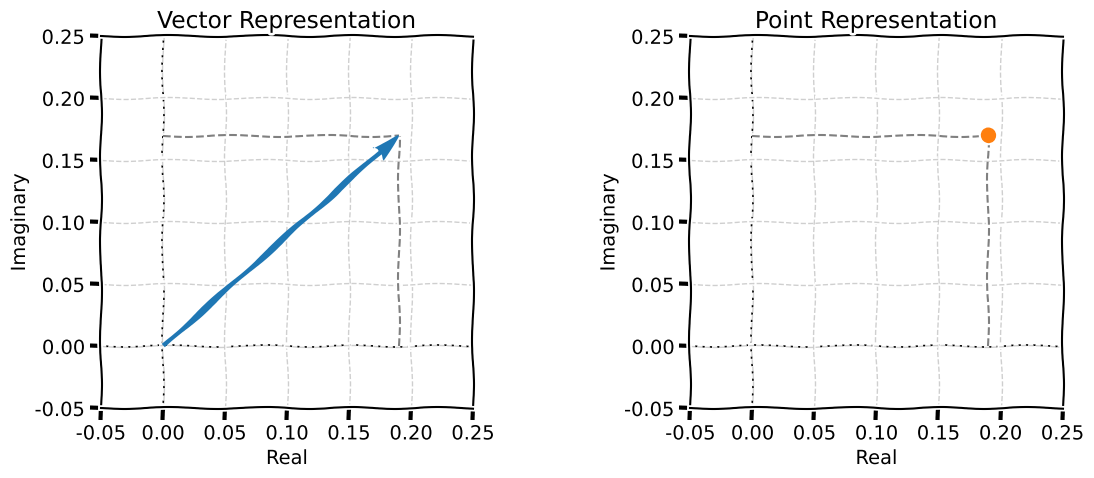

In [15]:

z = 0.19 + 0.17j
x = z.real
y = z.imag

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1,
           color='tab:blue', width=0.015, zorder=3)

ax1.plot([x, x], [0, y], color='gray', linestyle='--', linewidth=1.5, zorder=2)
ax1.plot([0, x], [y, y], color='gray', linestyle='--', linewidth=1.5, zorder=2)

ax1.set_title('Vector Representation')

ax2.plot(x, y, marker='o', markersize=10, color='tab:orange',
         linestyle='None', zorder=3)

ax2.plot([x, x], [0, y], color='gray', linestyle='--', linewidth=1.5, zorder=2)
ax2.plot([0, x], [y, y], color='gray', linestyle='--', linewidth=1.5, zorder=2)
ax2.set_title('Point Representation')

# --- Formatting for both axes ---
for ax in (ax1, ax2):
    ax.set_xlim(-0.05, 0.25)
    ax.set_ylim(-0.05, 0.25)
    ax.set_aspect('equal', adjustable='box')

    ax.set_xlabel('Real')
    ax.set_ylabel('Imaginary')

    ax.axhline(0, color='black', linewidth=1.2, zorder=1)
    ax.axvline(0, color='black', linewidth=1.2, zorder=1)

    # Ensure the grid line width is > 0 (defaults to ~0.8)
    ax.grid(True, linestyle='--', alpha=0.6, linewidth=1, zorder=0)

plt.tight_layout()
plt.show()

# Complex number operations

So how is a **complex** number different than a 2D vector i.e a set of x and y coordinates ? The difference lies in the operations they support. The addition of two complex numbers A and B or two vectors A and B follows the same rule i.e the first coordinate (real part or x coordinate) of the result of the addition is the sum of the first coordinate of vector A with the first coordinate of vector B and the second coordinate of the result (imaginary part or y coordinate) is the sum of the second coordinate of vector A with the second coordinate of vector B. Geometrically this is the well-known parallelogram law.
Using complex number notation we have:

$$
A = 0.19 + j0.75 \\
B = 0.21 + j0.15 \\
C = (0.19+0.21) + j (0.75 + 0.15) = 0.40 + j 0.90 \\
$$

Using vector notation we have:
$$
A = (0.19, 0.75) \\
B = (0.21, 0.15) \\
C = (0.19+0.21, 0.75+0.15) \\
C = (0.40, 0.90) \\
$$


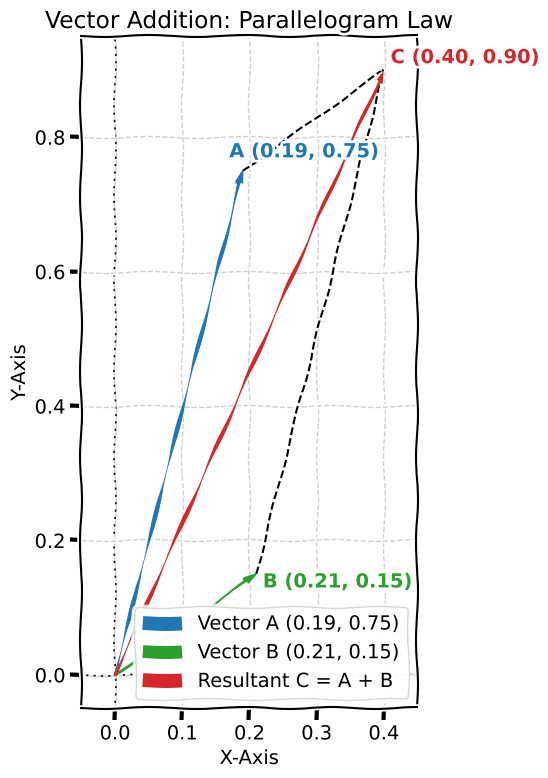

In [16]:
import matplotlib.pyplot as plt
import numpy as np

A = np.array([0.19, 0.75])
B = np.array([0.21, 0.15])

C = A + B

fig, ax = plt.subplots(figsize=(8, 8))
origin = np.array([0, 0])

# the three vectors
ax.quiver(*origin, *A, angles='xy', scale_units='xy', scale=1,
          color='tab:blue', width=0.008, label='Vector A (0.19, 0.75)', zorder=3)
ax.quiver(*origin, *B, angles='xy', scale_units='xy', scale=1,
          color='tab:green', width=0.008, label='Vector B (0.21, 0.15)', zorder=3)
ax.quiver(*origin, *C, angles='xy', scale_units='xy', scale=1,
          color='tab:red', width=0.008, label='Resultant C = A + B', zorder=3)

# Plot the dashed construction lines for the parallelogram
ax.plot([A[0], C[0]], [A[1], C[1]], color='black', linestyle='--', linewidth=1.5, zorder=2)
ax.plot([B[0], C[0]], [B[1], C[1]], color='black', linestyle='--', linewidth=1.5, zorder=2)

ax.text(A[0] - 0.02, A[1] + 0.02, f'A ({A[0]}, {A[1]})', color='tab:blue', fontweight='bold')
ax.text(B[0] + 0.01, B[1] - 0.02, f'B ({B[0]}, {B[1]})', color='tab:green', fontweight='bold')
ax.text(C[0] + 0.01, C[1] + 0.01, f'C ({C[0]:.2f}, {C[1]:.2f})', color='tab:red', fontweight='bold')

ax.set_xlim(-0.05, 0.45)
ax.set_ylim(-0.05, 0.95)

# Enforce equal aspect ratio so the parallelogram geometry isn't distorted
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('X-Axis')
ax.set_ylabel('Y-Axis')
ax.set_title('Vector Addition: Parallelogram Law')

ax.axhline(0, color='black', linewidth=1.2, zorder=1)
ax.axvline(0, color='black', linewidth=1.2, zorder=1)

# Add grid and legend
ax.grid(True, linestyle='--', alpha=0.6, linewidth=1, zorder=0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

Where things become interesting is the operation of multiplication. There are several different ways of "multiplying" vectors. One of these ways that we have already encountered is the dot-product (also sometimes called inner-product or scalar-product) but the resultant is a scalar not a vector. There is also the cross-product or vector product that returns a new vector, the Hadamard product which is the element-wise multiplication of the two vectors which seems like the most "natural" extension. Personally when it comes to vectors I found the use of the term multiplication more confusing than helpful for all these variants and prefer to simply think of them as operations on vectors that return either vectors or other types of mathematical objects such as scalars or matrices.



> COMPLEX NUMBERS ARE A GREAT REPRESENTATION FOR EXPRESSING ROTATIONS OF VECTORS

I personally like to think about this in terms of functions as we think of them in programming. Let's consider the function "Rotate 90 degress counter-clockwise" that takes as input a complex number corresponding to a vector and returns the complex number that is the vector rotated by 90 degress counter-clockwise. Geometrically we can see that if our original vector is (1,0) then the result of this operation will be (0,1). If we apply the same function the result will be (-1,0) and if we apply one more time (0,-1). After that the sequence repeats. We can easily visually see how this works.

Here comes the cool part. We can arrive at the same sequence by multiplying by $j$ and using the convention that $j^2$ is -1.
$$
\begin{align}
(1 + j 0) * j = j + j^2 0 = j + -1 * 0 = 0 + j \\
(0 + j) * j = -1 + j * 0 \\
(-1 + j * 0) * j  = 0 - j \\
\end{align}
$$

At the plots below you can see that multiplication by $j$ has the same effect (90 degrees rotation counter-clockwise) when our starting point/vector is (0.8,0.5).

**Exercise for the reader**: calculate the resulting sequence of complex numbers from the new starting vector using regular algebra and $j^2 = -1$. Experiment with different starting vectors.

We also would like complex number multiplication to behanve like real-number multiplication when the imaginary part is zero. The way complex number multiplication is typically defined it to follow the rules of algebra and replacing $j^2$ by -1 when it appears in an expression.
For example to multiply a + jb and c + jd:
$$
(a + jb) \cdot (c + jd) = (ac - bd) + j(ad + bc)
$$
the $-bd$ terms appears when $j^2$ is replaced by -1.

**Exercise for the reader**: Verify that this operation has the commutative and distributive properties of ordinary real number multiplication.

Note that the use of $j$ is a notation convention that allows us to do the operation using our knowledge of regular algebra but is not required. We can define the function without any use of j. One could still perform the operation without the $j$ convention as long as they memorize the formula for how the real and imaginary parts of the result are calculated from the real and imaginary parts of the two complex numbers that are being multiplied. The Python code below does just that without use of j.


In [17]:
def complex_number_multiplication(xr, xi, yr, yi):
  return (xr * yr - xi * yi, xr * yi + xi * yr)

(zr, zi) = complex_number_multiplication(0.8, 0.5, 0.3, 0.3)
print((zr, zi))

(0.09, 0.39)


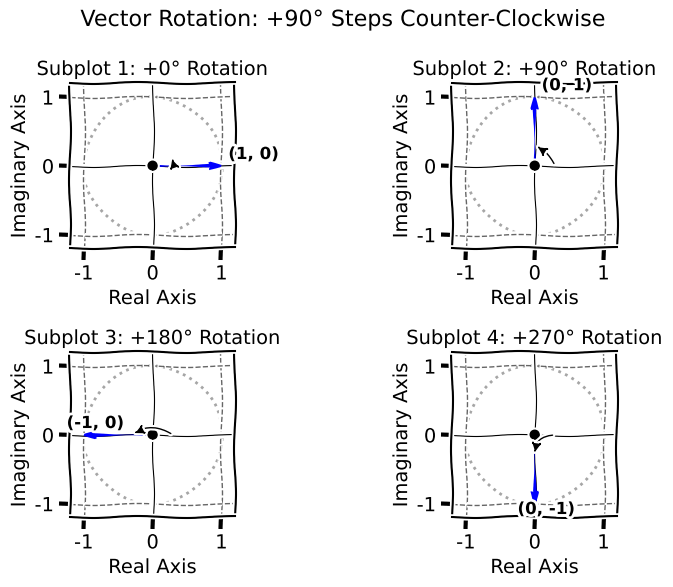

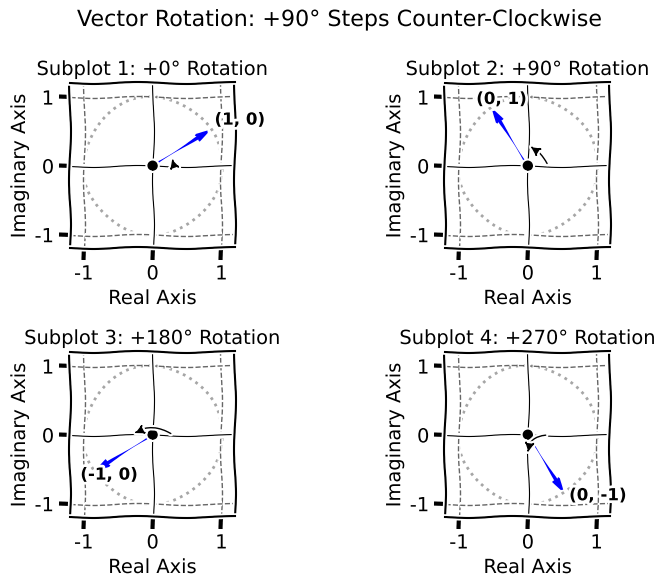

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch


def draw_four_rotations(x,y):

  # Define the starting vector and calculate its magnitude and initial phase
  z0 = complex(x,y)
  r = np.abs(z0)
  theta0 = np.angle(z0)


  angles_deg = [0, 90, 180, 270]
  angles_rad = np.deg2rad(angles_deg)

  # Set up a 2x2 grid of subplots
  fig, axs = plt.subplots(2, 2, figsize=(10, 6))
  fig.suptitle('Vector Rotation: +90° Steps Counter-Clockwise', fontsize=16)

  # unit circle
  theta_circle = np.linspace(0, 2*np.pi, 100)
  circle_x = np.cos(theta_circle)
  circle_y = np.sin(theta_circle)

  # Iterate through each subplot and its corresponding angle
  for i, (ax, deg, rad) in enumerate(zip(axs.flat, angles_deg, angles_rad)):

    z = z0 * np.exp(1j * rad)
    x, y = z.real, z.imag
    # Draw the unit circle
    ax.plot(circle_x, circle_y, linestyle=':', color='gray', alpha=0.7, zorder=1)

    # Draw the main rotating vector
    ax.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1,
              color='blue', width=0.015, zorder=3)

    # Draw the origin point
    ax.plot(0, 0, marker='o', color='black', zorder=4)

    # Add coordinate text near the tip of the vector
    # Offset slightly based on the quadrant to prevent overlapping
    offset_x = 0.1 if x >= 0 else -0.25
    offset_y = 0.1 if y >= 0 else -0.15
    ax.text(x + offset_x, y + offset_y, f'({int(np.round(x))}, {int(np.round(y))})',
            fontsize=12, fontweight='bold')

    # Draw the curved rotation indicator arrow
    if deg > 0:
        # Draw arc from 0 degrees up to the current angle
        arc = FancyArrowPatch(posA=(0.3, 0), posB=(0.3*np.cos(rad), 0.3*np.sin(rad)),
                              connectionstyle=f"arc3,rad={0.3 * (deg/180)}",
                              arrowstyle="-|>", mutation_scale=15, color='black', zorder=4)
        ax.add_patch(arc)
    else:
        # For 0 degrees, just show a small starting arc to indicate intended direction
        arc = FancyArrowPatch(posA=(0.3, 0), posB=(0.3*np.cos(0.5), 0.3*np.sin(0.5)),
                              connectionstyle="arc3,rad=0.1",
                              arrowstyle="-|>", mutation_scale=15, color='black', zorder=4)
        ax.add_patch(arc)

    # Formatting the subplot
    ax.set_title(f'Subplot {i+1}: +{deg}° Rotation', fontsize=14)
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect('equal', adjustable='box')

    ax.set_xlabel('Real Axis')
    ax.set_ylabel('Imaginary Axis')

    # Main axes lines
    ax.axhline(0, color='black', linewidth=0.8, zorder=2)
    ax.axvline(0, color='black', linewidth=0.8, zorder=2)

    # Grid lines (linewidth=1 to prevent the ValueError)
    ax.grid(True, linestyle='--', alpha=0.6, color='black', linewidth=1, zorder=0)
    # Adjust layout to prevent overlap and display
    plt.tight_layout()
  return fig, axs

(fig, ax) = draw_four_rotations(1.0, 0.0)
(fig, ax) = draw_four_rotations(0.8, 0.5)


We also would like complex number multiplication to behanve like real-number multiplication when the imaginary part is zero. The way complex number multiplication is typically defined it to follow the rules of algebra and replacing $j^2$ by -1 when it appears in an expression.
For example to multiply a + jb and c + jd:
$$
(a + jb) \cdot (c + jd) = (ac - bd) + j(ad + bc)
$$
the $-bd$ terms appears when $j^2$ is replaced by -1.

**Exercise for the reader**: Verify that this operation has the commutative and distributive properties of ordinary real number multiplication.

Note that the use of $j$ is a notation convention that allows us to do the operation using our knowledge of regular algebra but is not required. We can define the function without any use of j. One could still perform the operation without the $j$ convention as long as they memorize the formula.

The real beauty of complex number multiplication is revealed when we think of complex numbers as vectors in **polar form** i.e described in terms of the vector length and angle rather than the $x$ and $y$ coordinates.

The length of a complex number z = a + jb, is called the **magnitude** and written $|z|$ and is the Euclidean length of the vector line, interpreting $x$ and $y$ as coordinates:



$$
\rule{0pt}{4ex} R = |z| = \sqrt{x^2 + y^2}
$$

The angle the vector maskes with the real axis, often called its **argument** or **arg** or **angle**, is written $ARG(z)$:
$$
\theta = ARG(z) = \arctan(b/a)
$$

We can also easily go back to the real and imaginary representation:
$$
\begin{align}
a = Rcos(\theta)  \\
b = Rsin(\theta)  \\
\end{align}  
$$

When the imaginary part of the complex number is $0$ then complex number multiplication should behave like regular number multiplication and the **magnitude** is equal to the real part. Also remember that multiplication with $j$ is rotation counter-clockwise by 90 degrees i.e the angle from 0 becomes 90 degrees and then 180 etc. So for angles it seems that multiplication of complex numbers results in addition of angles.

Complex number multiplication can be defined much more intuitively when we consider the complex numbers in polar form. We have two edge cases:

1. complex numbers with zero imaginary parts where the multiplication should behave like real number multiplication and

2. multiplication by j adds 90 degrees or $\pi/2$ to the angle

Based on these two edge caseas a reasonable definition for complex number multiplication could be that the magnitude of the result of the multiplication is the **product** of the magnitudes of the two complex numbers being multiplied and the angle is the **sum** of the angles of the two complex numbers being multiplied.

$$
\begin{align}
A = R_1 \angle \theta_1 \\
B = R_2  \angle \theta_2 \\
R = A \cdot B = R_1 \cdot R_2 \angle(\theta_1 + \theta2)
\end{align}
$$



This definition of complex number multiplication is indeed correct. We can actually verify this with some algebra:
$$
\begin{align}
a + jb = R_1 \angle \theta1 \\
c + jd = R_2 \angle \theta2  \\
\end{align}
$$
We can replace $a$ with $R_1 cos(\theta1)$ and $b$ with $R_1 sin(\theta1)$, simialrly for $c$ and $d$ and then use the definition of complex number multiplication based on the rules of albegra we covered and some triggonometry and we get:

$$
\begin{align}
R_1 R_2 [\cos(\theta1 + \theta2) + j \sin(\theta1 + \theta2)]
\end{align}
$$

> The magnitudes multiply and the angles add.

**Exercise for the reader**  Picture two vectors on the complex-number plane and assume you know their lengths. Try to visualize their product by first adding the corresponding angles and then stretch the unit vector by the product of their lenghts.
